In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_transformer

df=pd.read_csv('Project_description_and_data/claims_train.csv')

def transform_log_scale(df):
    df = df.copy()
    df['VehAge_1']=df['VehAge'] +1                   
    df['VehAge_log']=np.log(df['VehAge_1'])
    df['DrivAge_log']=np.log(df['DrivAge'])
    df['Density_log']=np.log(df['Density'])
    #df['VehGas'] = np.where(df['VehGas'] == 'Regular', 0, 1)
    df.drop(['VehAge', 'VehAge_1', 'DrivAge', 'Density'], axis=1, inplace=True)
    return df

# def transform_cat(df):
#     df = df.copy()
#     categorical_features = ['VehBrand', 'VehGas', 'Area', 'Region']
#     numerical_features = [col for col in df.columns if col not in categorical_features]
#     preprocessor = ColumnTransformer(
#     transformers=[
#         ('cat', OrdinalEncoder(), categorical_features),
#         ('num', StandardScaler(), numerical_features)],
#          remainder='passthrough')
#     preprocessor.set_output(transform="pandas")
#     new_df = preprocessor.fit_transform(df)
#     new_df.columns = [col.split("__")[-1] for col in new_df.columns]
#     return new_df
    

# d = transform_scale(df)
# dd = transform_cat(d)
df

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,2122523.0,0,0.43,D,7,18,36,95,B1,Regular,1054,R24
1,3173420.0,0,0.10,D,7,17,80,95,B2,Regular,598,R25
2,1188619.0,0,0.33,E,7,3,36,76,B6,Regular,4172,R82
3,31400.0,0,0.56,A,5,4,73,52,B13,Diesel,15,R24
4,3138755.0,0,0.27,E,8,0,37,50,B11,Diesel,3021,R53
...,...,...,...,...,...,...,...,...,...,...,...,...
542405,2063494.0,0,0.20,D,6,10,32,76,B2,Diesel,1314,R24
542406,4164964.0,0,0.06,D,10,14,34,60,B5,Diesel,685,R72
542407,3078112.0,0,0.34,C,6,8,32,95,B5,Diesel,242,R82
542408,1012927.0,0,0.72,E,9,7,39,72,B2,Regular,3301,R73


In [4]:
df=pd.read_csv('Project_description_and_data/claims_test.csv')
df

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1135885,0,1.00,E,5,8,46,50,B1,Regular,4116,R24
1,51280,0,0.24,D,4,10,46,64,B1,Regular,1329,R11
2,6112464,0,0.41,C,4,0,32,72,B12,Regular,377,R73
3,3245787,0,0.07,C,5,4,57,50,B2,Diesel,251,R93
4,168150,0,0.06,B,4,10,45,50,B2,Regular,94,R53
...,...,...,...,...,...,...,...,...,...,...,...,...
135598,2118590,0,0.35,D,10,6,57,85,B12,Diesel,879,R82
135599,3020007,0,0.87,D,10,10,46,56,B5,Diesel,1609,R11
135600,1089081,0,1.00,E,8,8,35,50,B5,Regular,3744,R93
135601,6104970,0,0.50,E,11,1,32,54,B12,Regular,6485,R11


In [3]:
def transform_cat(df):
    df = df.copy()

    categorical_features = ['VehBrand', 'VehGas', 'Area', 'Region']
    numerical_features = [col for col in df.columns if col not in categorical_features]

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
            ('num', 'passthrough', numerical_features)
        ],
        remainder='drop'
    )

    preprocessor.set_output(transform="pandas")
    new_df = preprocessor.fit_transform(df)

    new_df.columns = [col.split("__")[-1] for col in new_df.columns]
    return new_df
transform_cat(df)

,VehBrand_B1,VehBrand_B10,VehBrand_B11,VehBrand_B12,VehBrand_B13,VehBrand_B14,VehBrand_B2,VehBrand_B3,VehBrand_B4,VehBrand_B5,...,Region_R93,Region_R94,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2122523.0,0,0.43,7,18,36,95,1054
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,3173420.0,0,0.10,7,17,80,95,598
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1188619.0,0,0.33,7,3,36,76,4172
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,31400.0,0,0.56,5,4,73,52,15
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3138755.0,0,0.27,8,0,37,50,3021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542405,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,2063494.0,0,0.20,6,10,32,76,1314
542406,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,4164964.0,0,0.06,10,14,34,60,685
542407,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,3078112.0,0,0.34,6,8,32,95,242
542408,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1012927.0,0,0.72,9,7,39,72,3301


PC1: 27.11%, PC2: 18.64%, Total: 45.75%
                  PC1       PC2
ClaimNb     -0.005707 -0.399182
DrivAge_log -0.647015 -0.111974
VehPower    -0.111849  0.556045
VehAge_log   0.269054 -0.475456
Density_log  0.182563  0.540620
BonusMalus   0.680522  0.024528


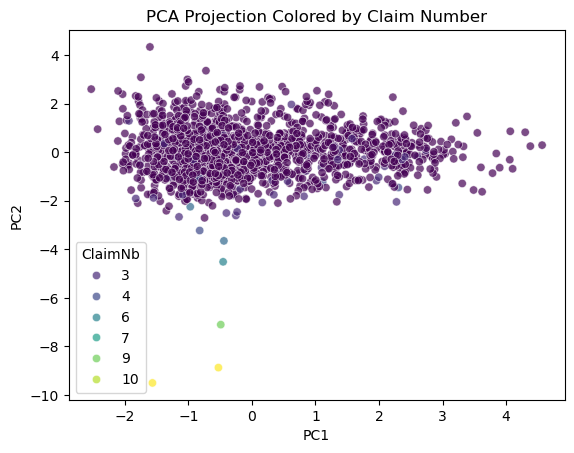

In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('Project_description_and_data/claims_train.csv')

def pca(df):
    df=df.copy()
    df = transform_log_scale(df)
    df=df[df['ClaimNb']>1] 

    features = ['ClaimNb', 'DrivAge_log', 'VehPower', 'VehAge_log', 'Density_log', 'BonusMalus']

    X = df[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)   # for 2D visualization
    X_pca = pca.fit_transform(X_scaled)

    df["PC1"] = X_pca[:, 0]
    df["PC2"] = X_pca[:, 1]

    explained = pca.explained_variance_ratio_ 
    print(f"PC1: {explained[0]:.2%}, PC2: {explained[1]:.2%}, Total: {explained[:2].sum():.2%}")

    loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
    )
    print(loadings)
    return df

def visualisation(df):
    df_pca = pca(df)
    sns.scatterplot(
        x="PC1",
        y="PC2",
        hue="ClaimNb",
        data=df_pca,
        palette="viridis",
        alpha=0.7
    )
    plt.title("PCA Projection Colored by Claim Number")
    plt.show()

visualisation(df)

PC1: 27.11%, PC2: 18.64%, Total: 45.75%
                  PC1       PC2
ClaimNb     -0.005707 -0.399182
DrivAge_log -0.647015 -0.111974
VehPower    -0.111849  0.556045
VehAge_log   0.269054 -0.475456
Density_log  0.182563  0.540620
BonusMalus   0.680522  0.024528
7


C:\Users\karat\AppData\Local\Temp\ipykernel_25312\2363732209.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


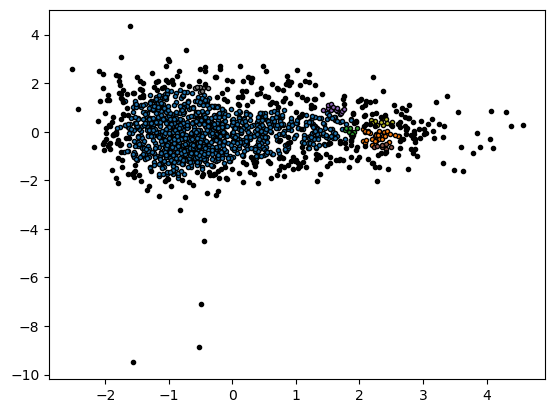

In [12]:
from sklearn.cluster import DBSCAN

def cluster_dbscan(df):
    df=df.copy()
    df=pca(df)
    X = df[['PC1', 'PC2']].values
    db = DBSCAN(eps=0.19, min_samples=10).fit(X)
    core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True
    labels = db.labels_
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    print(n_clusters_)
    unique_labels = set(labels)
    colors = plt.cm.get_cmap('tab10', len(unique_labels))

    for k, col in zip(unique_labels, colors(np.arange(len(unique_labels)))):
        if k == -1:
            col = (0, 0, 0, 1)  # black for noise

        class_member_mask = (labels == k)
        xy = X[class_member_mask]
    
        plt.plot(xy[:, 0], xy[:, 1], 'o',
            markerfacecolor=col,
            markeredgecolor='k',
            markersize=3)

cluster_dbscan(df)

In [ ]:
# def transform_cat(df):
#     df = df.copy()
#     categorical_features = ['VehBrand', 'VehGas', 'Area', 'Region']
#     numerical_features = [col for col in df.columns if col not in categorical_features]
#     preprocessor = ColumnTransformer(
#     transformers=[
#         ('cat', OrdinalEncoder(), categorical_features),
#         ('num', StandardScaler(), numerical_features)],
#          remainder='passthrough')
#     preprocessor.set_output(transform="pandas")
#     new_df = preprocessor.fit_transform(df)
#     new_df.columns = [col.split("__")[-1] for col in new_df.columns]
#     return new_df  


#There is something weird with this, it creates new columns. I tried with OrdinalEncoder and it worked, but then I changed it back because I read that it is not stable(?) - I will look into it<3
# def transform_cat(df):
#     df = df.copy()

#     categorical_features = ['VehBrand', 'VehGas', 'Area', 'Region']
#     numerical_features = [col for col in df.columns if col not in categorical_features]

#     preprocessor = ColumnTransformer(
#         transformers=[
#             ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
#             ('num', 'passthrough', numerical_features) #does not contain Standard Scaler becase not all models need that, pls apply manually
#         ],
#         remainder='drop'
#     )

#     preprocessor.set_output(transform="pandas")
#     new_df = preprocessor.fit_transform(df)

#     new_df.columns = [col.split("__")[-1] for col in new_df.columns]
#     return new_df